# DATASET - Flickr Faces Dataset Resized #

Este dataset incluye imagenes de rostros de personas de diferentes caracteristicas, la utilidad que voy a buscar con este dataset sera aplicar aprendizaje no supervisado para tratar de agrupar las imagenes segun las caracteristicas de cada persona, color de piel, tipos de ojos, rasgos, etc. El kmeans deberia poder encontrar diferentes caracteristicas.


Uno de los desafios que espero encontrar puede ser el de eliminar el fondo para ver si este afecta mucho o no en la agrupacion del modelo a desarrollar.

Como voy a trabajar con imagenes algo pesadas, voy a tener que usar GPU, y pytorch

# 1 
Primero trabajar solo con CPU y con el cuadernillo estandar para ver si funciona bien o no

Al realizar el trabajo, me encontre con problemas de falta de memoria aun con el conjunto de datos de 64x64 asi que para lograr trabajar con menor memoria se reescalara la resolucion a 32x32 ya que consume mucho menos memoria que los 64x64 originales

In [5]:
import os
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split

def load_and_process_faces(path, size=(32, 32)):
    images = []
    valid_extensions = ('.jpg', '.jpeg', '.png', '.webp')
    files = [f for f in os.listdir(path) if f.lower().endswith(valid_extensions)]
    
    print(f"Procesando {len(files)} imágenes a resolución {size}...")

    for file in files:
        img_path = os.path.join(path, file)
        # 1. Abrir imagen
        img = Image.open(img_path).convert('RGB') 
        
        # 2. Redimensionar a 32x32 (o el tamaño deseado)
        # Usamos LANCZOS para mantener la mejor calidad posible al reducir
        img = img.resize(size, Image.Resampling.LANCZOS)
        
        img_data = np.asarray(img)
        
        # 3. Aplanar: de (32, 32, 3) a (3072,)
        images.append(img_data.flatten())

    return np.array(images)

# --- CONFIGURACIÓN ---
path_origen = r'C:\Users\aaran\Downloads\Flick Faces Dataset Resized\64x64\faces'
path_guardado = 'faces_32x32_flat.npy' # Nombre del archivo donde guardaremos

# 1. Cargar y redimensionar
X = load_and_process_faces(path_origen, size=(32, 32))

# 2. Normalizar
X = X.astype(np.float32) / 255.0

# 3. Guardar el dataset completo en disco
# Esto crea un solo archivo con todas las imágenes ya listas
np.save(path_guardado, X)
print(f"Dataset guardado exitosamente como {path_guardado}")

# 4. Split de entrenamiento y prueba
X_train, X_test = train_test_split(X, test_size=0.25, random_state=42)

print(f"Estructura final de X_train: {X_train.shape}") 
# Resultado esperado: (n_muestras, 3072) -> 3072 = 32*32*3

Procesando 52001 imágenes a resolución (32, 32)...
Dataset guardado exitosamente como faces_32x32_flat.npy
Estructura final de X_train: (39000, 3072)


In [15]:
## Metodo 2 para recortar las imagenes 
import os
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split

def load_and_process_faces(path, size=(32, 32), crop_factor=0.7):
    """
    Carga, recorta al centro y redimensiona imágenes.
    crop_factor: 1.0 es la imagen original, 0.7 toma el 70% central (más zoom).
    """
    images = []
    valid_extensions = ('.jpg', '.jpeg', '.png', '.webp')
    files = [f for f in os.listdir(path) if f.lower().endswith(valid_extensions)]
    
    print(f"Procesando {len(files)} imágenes con zoom de {crop_factor}...")

    for file in files:
        img_path = os.path.join(path, file)
        img = Image.open(img_path).convert('RGB')
        
        width, height = img.size
        
        # 1. Calcular el área de recorte (Center Crop)
        # Queremos un cuadrado basado en el lado más corto para no deformar
        new_dimension = min(width, height) * crop_factor
        
        left = (width - new_dimension) / 2
        top = (height - new_dimension) / 2
        right = (width + new_dimension) / 2
        bottom = (height + new_dimension) / 2

        # 2. Recortar
        img = img.crop((left, top, right, bottom))
        
        # 3. Redimensionar a 32x32
        img = img.resize(size, Image.Resampling.LANCZOS)
        
        img_data = np.asarray(img)
        images.append(img_data.flatten())

    return np.array(images)

# --- CONFIGURACIÓN ---
path_origen = r'C:\Users\aaran\Downloads\Flick Faces Dataset Resized\64x64\faces'
path_guardado = 'faces_32x32_cropped.npy'

# 1. Cargar con recorte (crop_factor=0.6 o 0.7 suele ser ideal para rostros)
X = load_and_process_faces(path_origen, size=(32, 32), crop_factor=0.65)

# 2. Normalizar
X = X.astype(np.float32) / 255.0

# 3. Guardar
np.save(path_guardado, X)
print(f"Dataset con recorte guardado como {path_guardado}")

Procesando 52001 imágenes con zoom de 0.65...
Dataset con recorte guardado como faces_32x32_cropped.npy


In [ ]:
import os
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split

path_guardado = 'faces_32x32_flat.npy' # Nombre del archivo donde guardaremos

X = np.load(path_guardado)  # Cargar el dataset completo para usarlo posteriormente
print(f"Dataset completo cargado: {X.shape}")

# 4. Split de entrenamiento y prueba
X_train, X_test = train_test_split(X, test_size=0.25, random_state=42)

print(f"Estructura final de X_train: {X_train.shape}") 
# Resultado esperado: (n_muestras, 3072) -> 3072 = 32*32*3

Dataset completo cargado: (52001, 3072)
Estructura final de X_train: (39000, 3072)


In [1]:
import os
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split

path_guardado = 'faces_32x32_cropped.npy' # Nombre del archivo donde guardaremos

X = np.load(path_guardado)  # Cargar el dataset completo para usarlo posteriormente
print(f"Dataset completo cargado: {X.shape}")

# 4. Split de entrenamiento y prueba
X_train, X_test = train_test_split(X, test_size=0.25, random_state=42)

print(f"Estructura final de X_train: {X_train.shape}") 
# Resultado esperado: (n_muestras, 3072) -> 3072 = 32*32*3

Dataset completo cargado: (52001, 3072)
Estructura final de X_train: (39000, 3072)


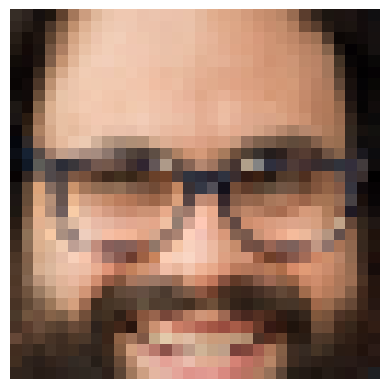

In [2]:
import matplotlib.pyplot as plt

# Tomar la primera imagen del set de entrenamiento
sample_img = X_train[0].reshape(32, 32, 3)
plt.imshow(sample_img)
plt.axis('off')
plt.show()

In [3]:
from sklearn.cluster import KMeans

k = 10
kmeans = KMeans(n_clusters=k, random_state=42)
X_digits_dist = kmeans.fit_transform(X_train)

In [4]:
print(X_digits_dist.shape)
print(X_digits_dist)

(39000, 10)
[[11.638817  14.351959  14.909749  ... 13.236995  11.736157  15.108742 ]
 [15.723723  14.999725  15.343903  ... 13.628727  16.047995  14.063678 ]
 [13.952425  14.5687275 15.490273  ... 14.708263  13.882908  12.423692 ]
 ...
 [11.509673  11.364121  15.621853  ... 11.158339   9.661757   9.98162  ]
 [11.368926  11.036214  15.815733  ... 11.279357   9.370828   8.7573595]
 [12.443371  10.057822  11.72383   ... 11.9389925 11.205173  11.980144 ]]


In [5]:
idxs = np.argmin(X_digits_dist, axis=0)
X_representative_digits = X_train[idxs]

In [6]:
print(X_representative_digits.shape)
print(X_representative_digits)

(10, 3072)
[[0.6039216  0.5137255  0.4392157  ... 0.4        0.3019608  0.16862746]
 [0.36078432 0.38039216 0.39607844 ... 0.6156863  0.54901963 0.5411765 ]
 [0.3764706  0.30980393 0.2627451  ... 0.32941177 0.2509804  0.19215687]
 ...
 [0.5803922  0.54901963 0.32941177 ... 0.8666667  0.85882354 0.90588236]
 [0.50980395 0.43529412 0.31764707 ... 0.43137255 0.4509804  0.43137255]
 [0.20392157 0.1764706  0.15294118 ... 0.53333336 0.6392157  0.38431373]]


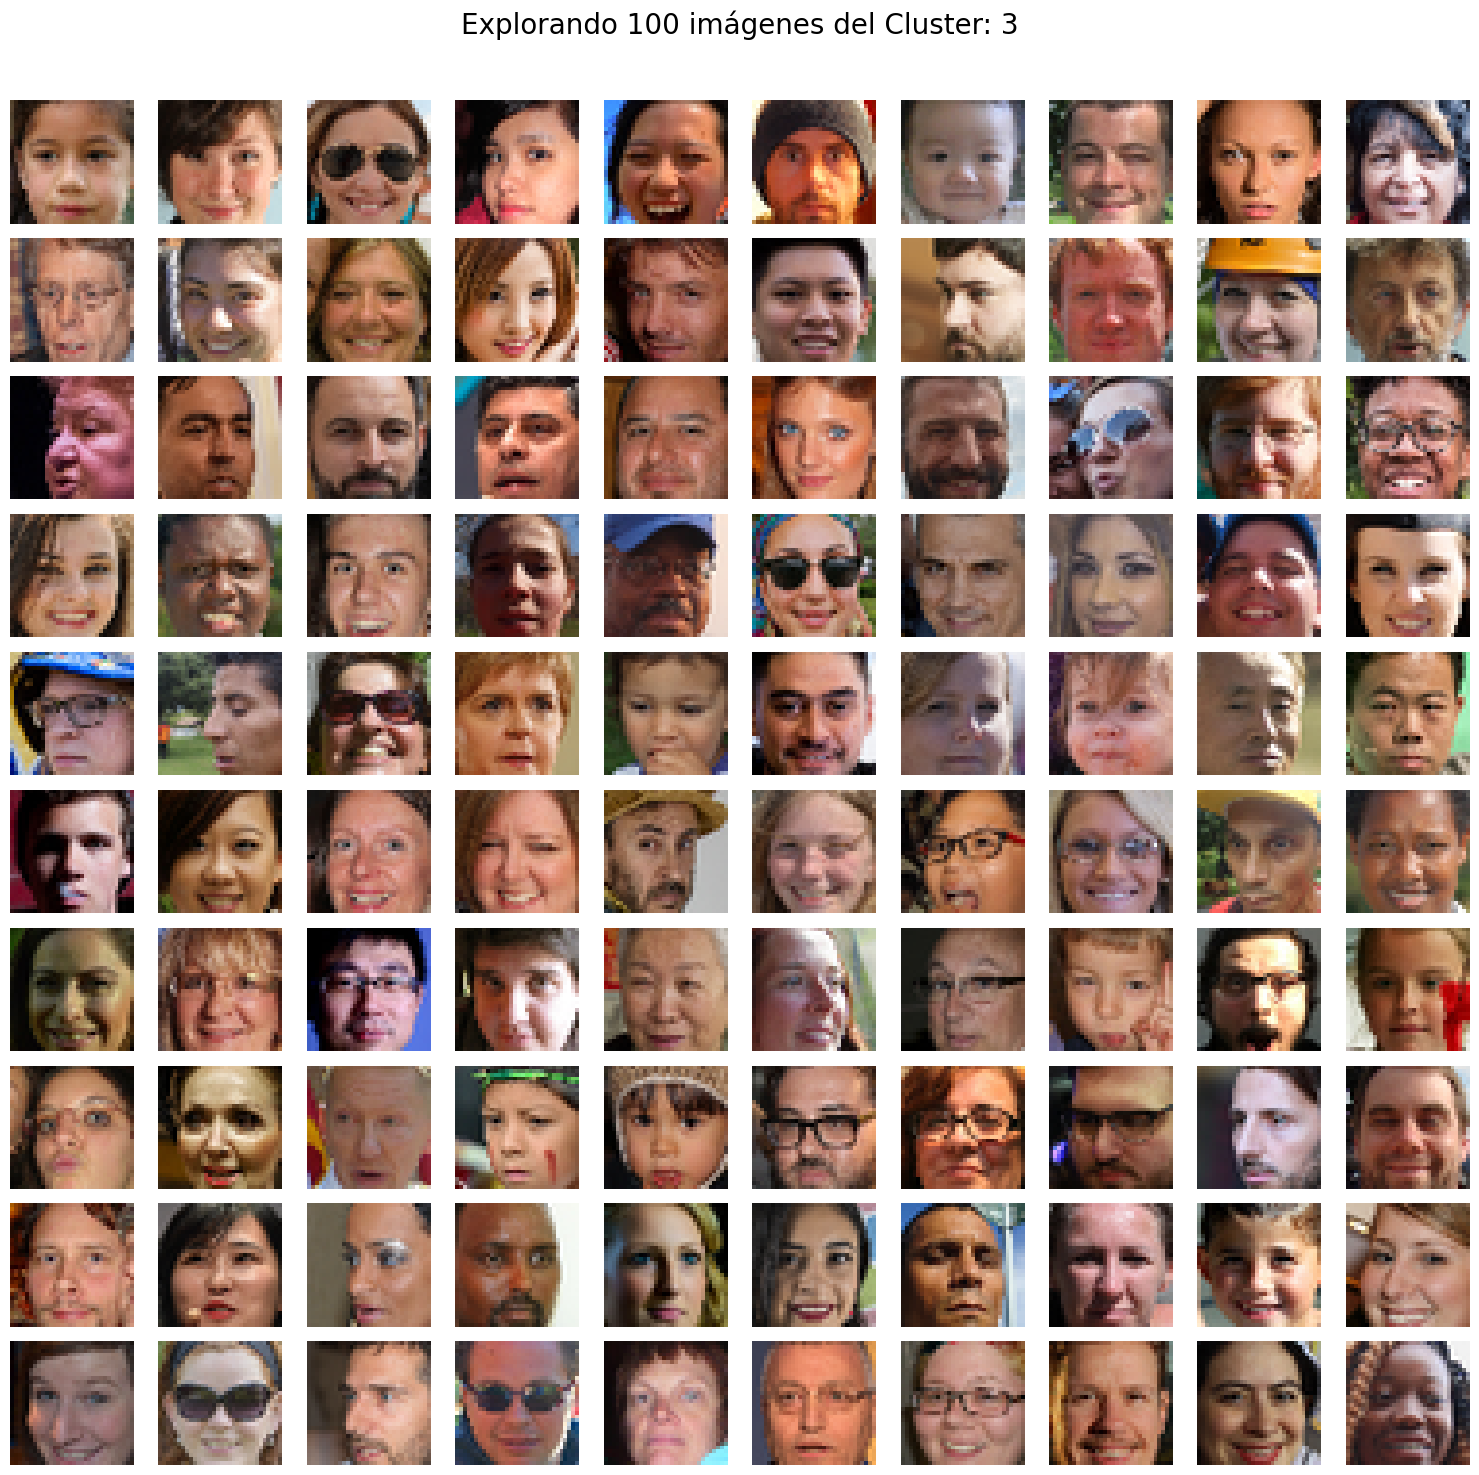

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# --- CONFIGURACIÓN ---
cluster_id = 3  # Cambia este número para ver otros clusters (0 a 9)
n_muestras = 100
grid_size = 10  # 10x10 = 100 imágenes

# 1. Obtener las etiquetas del modelo
labels = kmeans.labels_

# 2. Filtrar los índices de las imágenes que pertenecen al cluster elegido
indices = np.where(labels == cluster_id)[0]

# Verificamos si el cluster tiene suficientes imágenes
if len(indices) < n_muestras:
    print(f"Aviso: El cluster {cluster_id} solo tiene {len(indices)} imágenes.")
    n_muestras = len(indices)

# 3. Graficar
plt.figure(figsize=(15, 15))
plt.suptitle(f"Explorando 100 imágenes del Cluster: {cluster_id}", fontsize=20)

for i in range(n_muestras):
    plt.subplot(grid_size, grid_size, i + 1)
    
    # Obtenemos la imagen usando el índice filtrado
    img_idx = indices[i]
    img = X_train[img_idx].reshape(32, 32, 3)
    
    plt.imshow(img)
    plt.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.92) # Espacio para el título
plt.show()

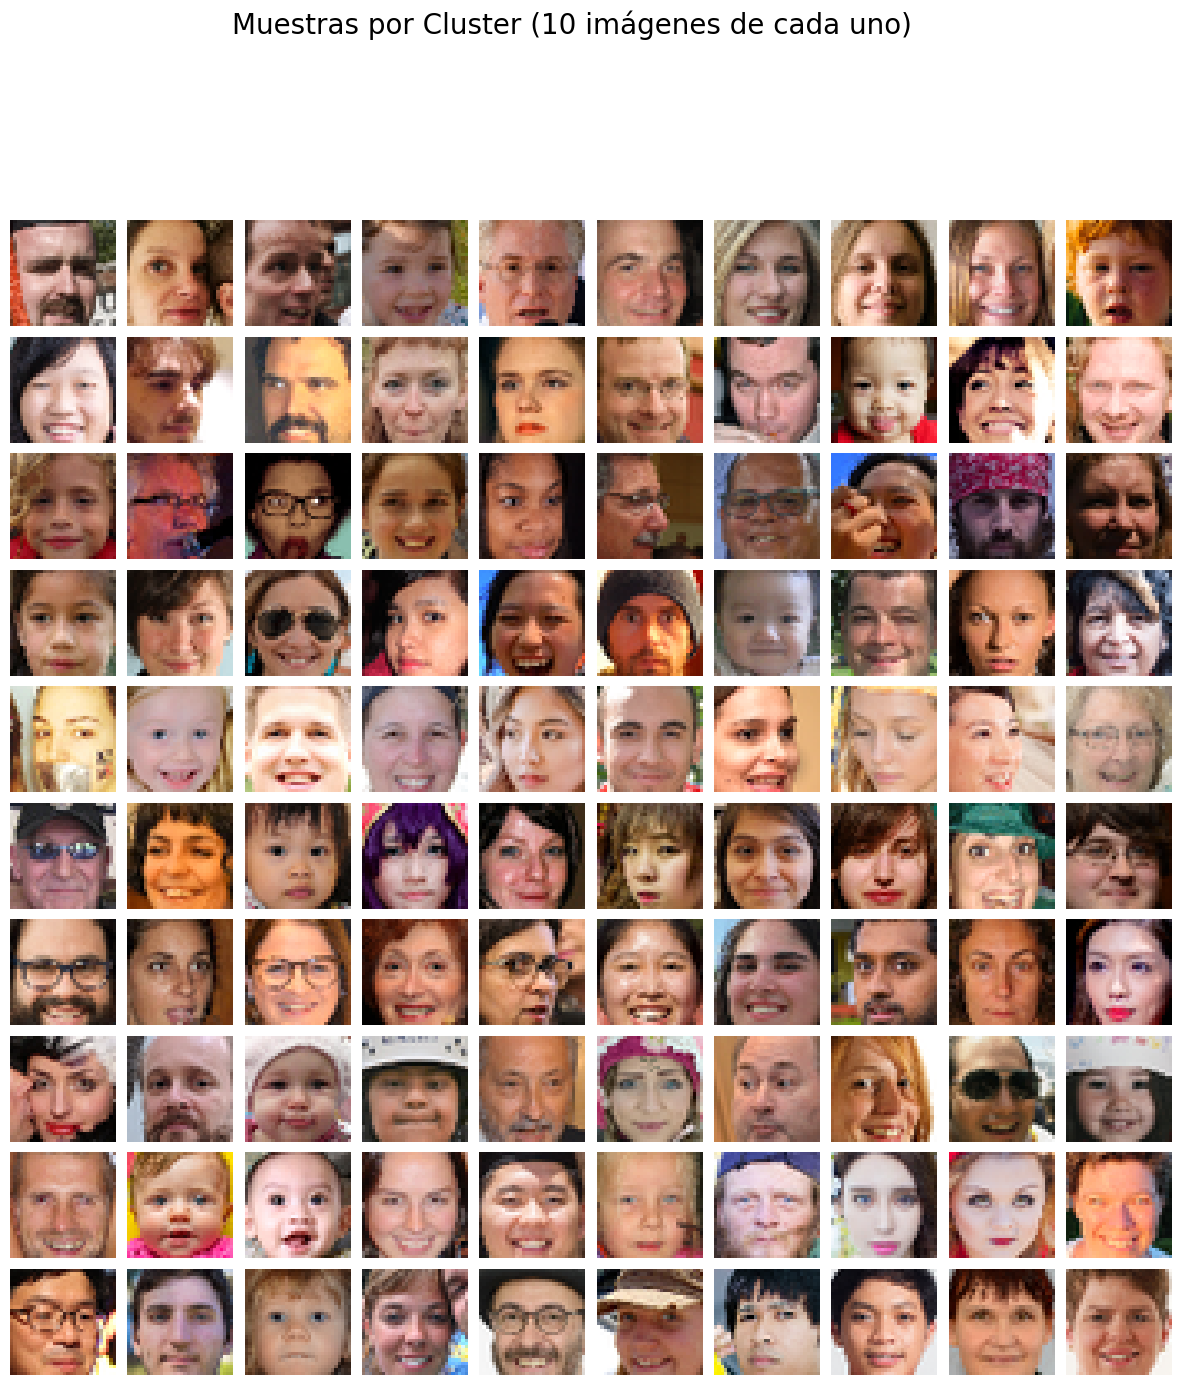

In [8]:
import matplotlib.pyplot as plt

# 1. Obtener las etiquetas de cada imagen en el set de entrenamiento
labels = kmeans.labels_

n_clusters = 10
samples_per_cluster = 10

# Crear la figura (filas = clusters, columnas = muestras)
fig, axes = plt.subplots(n_clusters, samples_per_cluster, figsize=(15, 15))

for i in range(n_clusters):
    # Encontrar los índices de las imágenes que pertenecen al cluster 'i'
    indices = np.where(labels == i)[0]
    
    # Tomar las primeras 'samples_per_cluster' imágenes de ese cluster
    # Usamos min() por si un cluster tiene menos de 10 imágenes
    for j in range(min(samples_per_cluster, len(indices))):
        img_idx = indices[j]
        img = X_train[img_idx].reshape(32, 32, 3)
        
        ax = axes[i, j]
        ax.imshow(img)
        ax.axis('off')
        
        # Poner el número del cluster solo en la primera columna
        if j == 0:
            ax.set_ylabel(f"Cluster {i}", rotation=0, labelpad=40, fontweight='bold')

plt.subplots_adjust(wspace=0.1, hspace=0.1)
plt.suptitle("Muestras por Cluster (10 imágenes de cada uno)", fontsize=20, y=1.02)
plt.show()

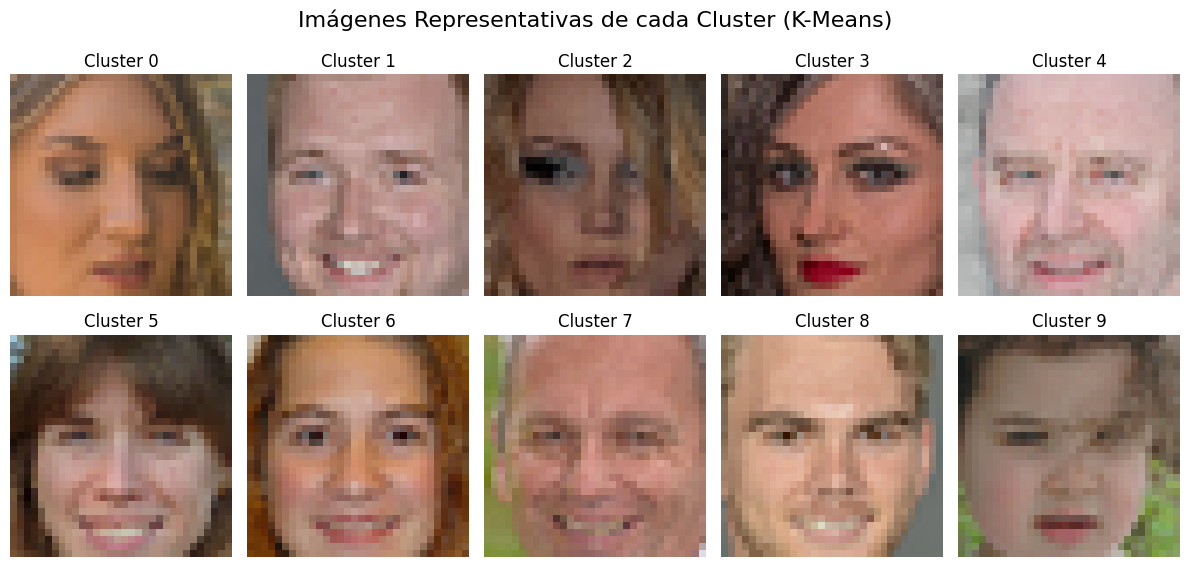

In [26]:
import matplotlib.pyplot as plt

# --- CONFIGURACIÓN DEL GRÁFICO ---
# Calculamos las dimensiones para el subplot basándonos en k
# Si k=10, una fila de 10 o dos de 5 queda bien.
n_rows = 2
n_cols = 5

plt.figure(figsize=(12, 6))
plt.suptitle("Imágenes Representativas de cada Cluster (K-Means)", fontsize=16)

for index, representative_face in enumerate(X_representative_digits):
    plt.subplot(n_rows, n_cols, index + 1)
    
    # IMPORTANTE: Reshape a (32, 32, 3) para color RGB
    # Tus datos originales eran (3072,) -> ahora vuelven a ser una matriz de imagen
    img_rgb = representative_face.reshape(32, 32, 3)
    
    plt.imshow(img_rgb)
    plt.title(f"Cluster {index}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [8]:
def load_next_batch(batch_size):
    return X[np.random.choice(len(X), batch_size, replace=False)]

In [4]:
best_kmeans.score(X)

-26715032.820473105

In [ ]:
idxs = np.argmin(X_digits_dist, axis=0)
X_representative_digits = X_train.values[idxs]

In [3]:
import torch

print(torch.version.cuda)        # debería mostrar '12.1'
print(torch.cuda.is_available()) # debería ser True


13.0
True


In [1]:
import torch

print("Versión de PyTorch:", torch.__version__)
print("Versión de CUDA en PyTorch:", torch.version.cuda)
print("CUDA disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("Nombre de GPU:", torch.cuda.get_device_name(0))
    # Crear un tensor en GPU
    x = torch.rand(10000, 10000, device="cuda")
    print("Tensor creado en GPU:", x.device)
else:
    print("⚠️ PyTorch no detecta la GPU")


Versión de PyTorch: 2.11.0+cu130
Versión de CUDA en PyTorch: 13.0
CUDA disponible: True
Nombre de GPU: NVIDIA GeForce RTX 4050 Laptop GPU
Tensor creado en GPU: cuda:0


In [3]:
# Verificar si CUDA está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando el dispositivo: {device}")

Usando el dispositivo: cuda


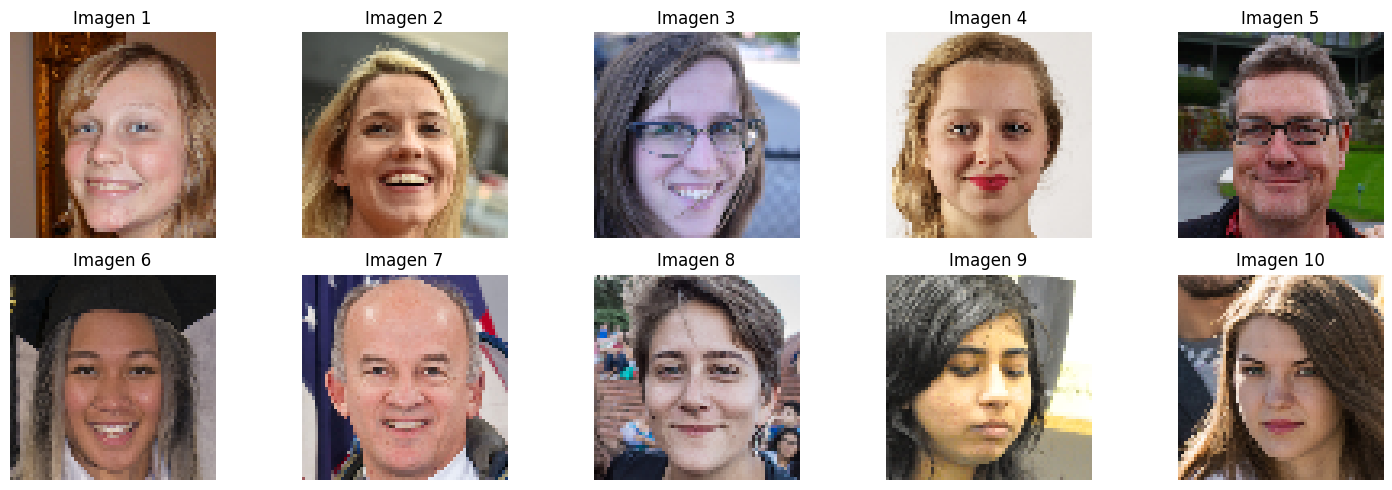

Dataset cargado con 52001 imágenes.
Listo para enviar a: cuda


In [7]:
import os
import torch
from torchvision import transforms
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt

# 1. Definir la ruta (Usa la carpeta padre de 'faces')
path = r"C:\Users\aaran\Downloads\Flick Faces Dataset Resized\64x64"

# 2. Carga mínima: solo convertir a Tensor para que sea compatible con PyTorch
# No aplicamos normalización ni redimensionamiento extra
dataset = ImageFolder(root=path, transform=transforms.ToTensor())

# 3. Función para visualizar las primeras 10 imágenes
def visualizar_muestras(dataset, n=10):
    plt.figure(figsize=(15, 5))
    for i in range(n):
        # dataset[i] devuelve una tupla (imagen, etiqueta)
        imagen, _ = dataset[i] 
        
        # PyTorch carga como (C, H, W), Matplotlib necesita (H, W, C)
        imagen_permuted = imagen.permute(1, 2, 0)
        
        plt.subplot(2, 5, i + 1)
        plt.imshow(imagen_permuted)
        plt.axis('off')
        plt.title(f"Imagen {i+1}")
    plt.tight_layout()
    plt.show()

visualizar_muestras(dataset)

# 4. Confirmar carga en CUDA (opcional para verificar)
dispositivo = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dataset cargado con {len(dataset)} imágenes.")
print(f"Listo para enviar a: {dispositivo}")

In [8]:
from sklearn.model_selection import train_test_split

# Dividimos el dataset en 80% train y 20% test
train_data, test_data = train_test_split(dataset, test_size=0.2, random_state=42)

print(f"Entrenamiento: {len(train_data)}")
print(f"Pruebas: {len(test_data)}")

Entrenamiento: 41600
Pruebas: 10401


In [17]:
def load_next_batch(batch_size):
    return X[np.random.choice(len(X), batch_size, replace=False)]